Auteur: Abdelkirm AKKAL

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join("..","python")))

from model_linear import lib, entrainer_linear, precision_linear, predire_linear
from functions import load_dataset, melanger

In [2]:
def courbe(x, y, xlabel, ylabel, titre, log=False):
    plt.plot(x, y, marker="o")
    if log:
        plt.xscale("log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titre)
    plt.show()


def courbe_train_test(hist_train, hist_test, ylabel, titre):
    plt.figure(figsize=(10, 5))
    plt.plot(hist_train, label="train")
    plt.plot(hist_test, label="test")
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.title(titre)
    plt.show()

def courbe_multi(historiques, couleurs, ylabel, titre):
    plt.figure(figsize=(10, 5))
    for cle, valeurs in historiques.items():
        resolution, couleur = cle
        label = f"{resolution}x{resolution} {'couleur' if couleur else 'gris'}"

        # (x, y)
        plt.plot([i for i in range(1, len(valeurs)+1)], valeurs,label=label, color=couleurs[cle])

    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.title(titre)
    plt.legend(loc="lower left")
    plt.show()

In [3]:
#1. Dataset

project_root = os.path.abspath("..")
train_folder = os.path.join(project_root, "dataset", "train_dataset")
test_folder = os.path.join(project_root, "dataset", "test_dataset")

configs = {}
for resolution in (16, 32):
    for couleur in (False, True):
        X_train, Y_train = load_dataset(train_folder, target_size=(resolution, resolution), color=couleur)
        X_test, Y_test = load_dataset(test_folder, target_size=(resolution, resolution), color=couleur)
        X_train, Y_train = melanger(X_train, Y_train, seed=42)

        configs[(resolution, couleur)] = (X_train, Y_train, X_test, Y_test)

for cle, (X_train, Y_train, X_test, Y_test) in configs.items():
    print(f"{cle}: train={len(X_train)}, test={len(X_test)}")

(16, False): train=2400, test=600
(16, True): train=2400, test=600
(32, False): train=2400, test=600
(32, True): train=2400, test=600


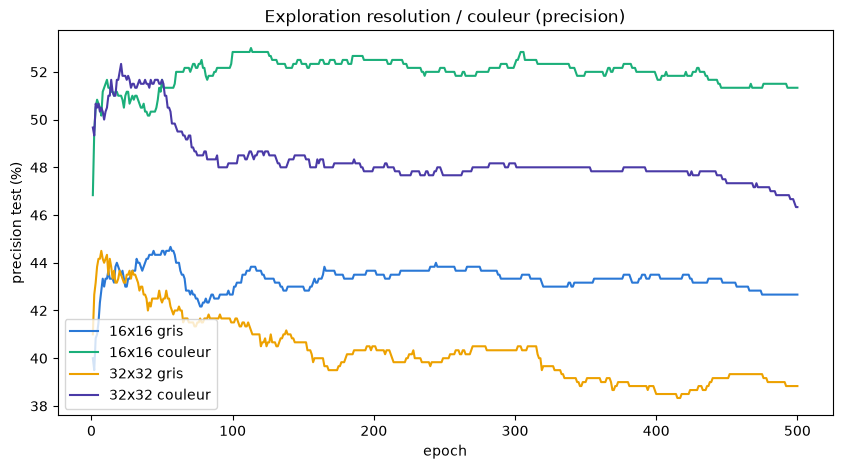

In [4]:
#2. Exploration (resolution/ couleurs/ epochs)

EPOCHS_EXPLO = 500
LR = 0.0001

couleurs_courbe = {
    (16, False): "#2a78d6",
    (16, True): "#1baf7a",
    (32, False): "#eda100",
    (32, True): "#4a3aa7",
}

historiques = {}
for cle, (X_train, Y_train, X_test, Y_test) in configs.items():
    model, hist_train, hist_test, err_train, err_test = entrainer_linear(
        X_train, Y_train, output_size=3, epochs=EPOCHS_EXPLO, lr=LR,
        X_test=X_test, Y_test=Y_test
    )

    # (16, True): [15, ....]
    historiques[cle] = hist_test
    lib.destroy_linear_model(model)

courbe_multi(historiques, couleurs_courbe, "precision test (%)", "Exploration resolution / couleur (precision)")

In [5]:
recap = []
for (resolution, couleur), hist_test in historiques.items():
    meilleur_epoch = int(np.argmax(hist_test)) +1
    recap.append((resolution, couleur, meilleur_epoch, hist_test[meilleur_epoch - 1]))

# r[3]: on trie sur le 3eme element (hist_test)
recap.sort(key=lambda r: r[3], reverse=True)

print(f"{'Config':<16}{'Epoch':>7}{'Test%':>8}")
for resolution, couleur, epoch, acc in recap:
    config = f"{resolution}x{resolution} {'couleur' if couleur else 'gris'}"
    print(f"{config:<16}{epoch:>7}{acc:>7.2f}%")

Config            Epoch   Test%
16x16 couleur       113  53.00%
32x32 couleur        21  52.33%
16x16 gris           56  44.67%
32x32 gris            7  44.50%


In [6]:
# choix du meilleur resolution
X_train, Y_train, X_test, Y_test = configs[(16, True)]
resolution, couleur, meilleur_epoch, acc = recap[0]




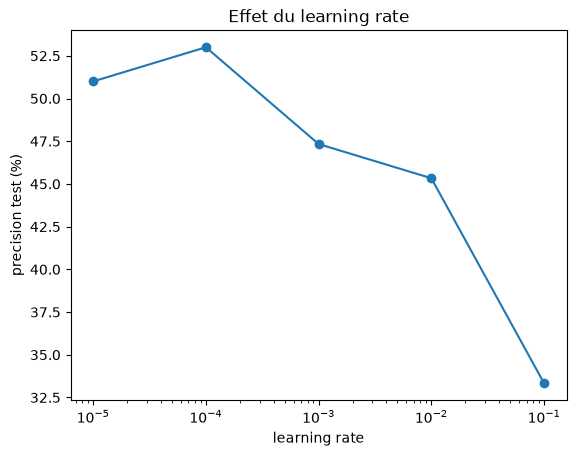

In [7]:
#3. Affinage (learning rate)

lrs = [0.1, 0.01, 0.001, 0.0001, 0.00001]
accs_lr = []

for lr in lrs:
    model = entrainer_linear(X_train, Y_train, output_size=3, epochs=meilleur_epoch, lr=lr)
    accs_lr.append(precision_linear(model, X_test, Y_test))

meilleur_lr = lrs[int(np.argmax(accs_lr))]

courbe(lrs, accs_lr, "learning rate", "precision test (%)", "Effet du learning rate", log=True)


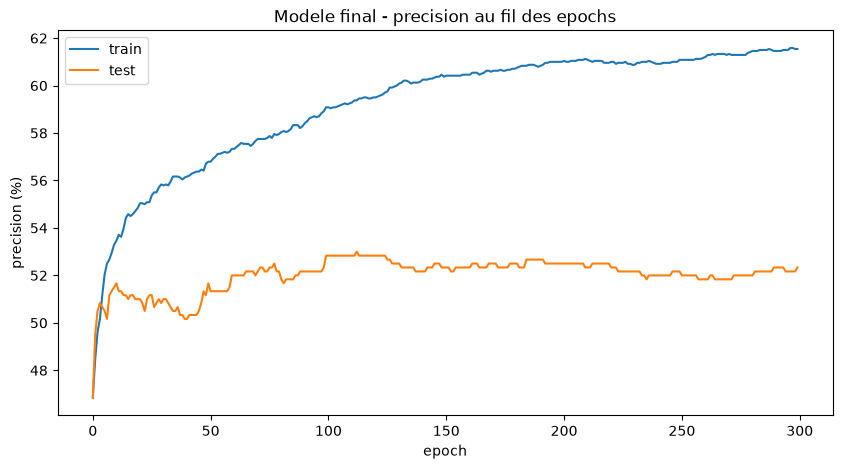

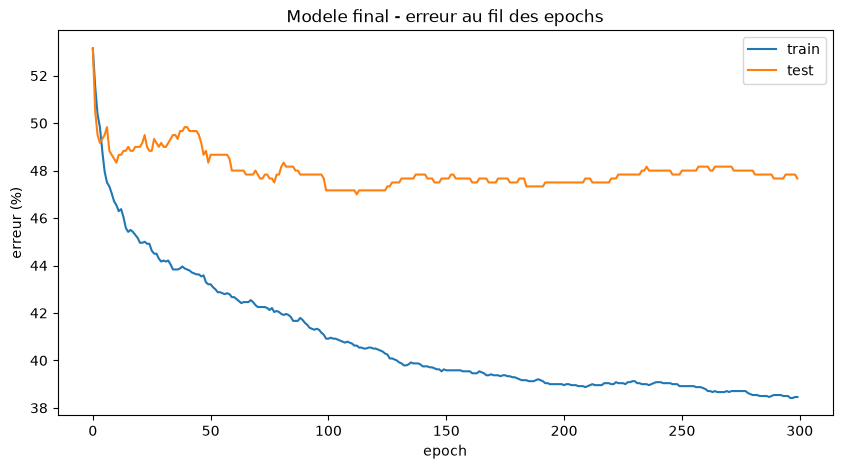

meilleur epoch = 113
train=59.38%  test=53.00%


In [8]:
#4. Modele Final

# entrainement long, juste pour tracer les courbes et reperer le meilleur epoch
model, hist_train, hist_test, err_train, err_test = entrainer_linear(
    X_train, Y_train, output_size=3, epochs=300, lr=meilleur_lr,
    X_test=X_test, Y_test=Y_test
)
lib.destroy_linear_model(model)

meilleur_epoch = int(np.argmax(hist_test)) + 1

courbe_train_test(hist_train, hist_test, "precision (%)", "Modele final - precision au fil des epochs")
courbe_train_test(err_train, err_test, "erreur (%)", "Modele final - erreur au fil des epochs")

# re-entrainement arrete au meilleur epoch : init (srand 42) et shuffle (seed 42)
# sont deterministes, donc on retombe exactement sur le modele de cet epoch
model = entrainer_linear(X_train, Y_train, output_size=3, epochs=meilleur_epoch, lr=meilleur_lr)

print(f"meilleur epoch = {meilleur_epoch}")
print(f"train={hist_train[meilleur_epoch - 1]:.2f}%  test={hist_test[meilleur_epoch - 1]:.2f}%")

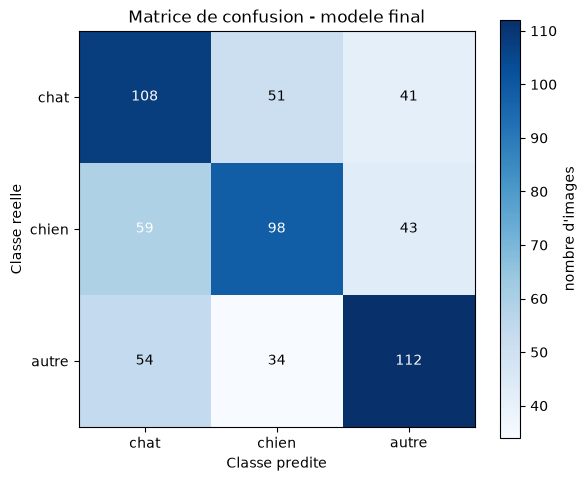

In [9]:
noms_classes = ["chat", "chien", "autre"]

def matrice_confusion(model, X, Y, nb_classes=3):
    matrice = np.zeros((nb_classes, nb_classes), dtype=int)
    for x, y_vrai in zip(X, Y):
        y_pred = predire_linear(model, x)
        matrice[y_vrai][y_pred] += 1
    return matrice

cm = matrice_confusion(model, X_test, Y_test)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(noms_classes)))
ax.set_yticks(range(len(noms_classes)))
ax.set_xticklabels(noms_classes)
ax.set_yticklabels(noms_classes)
ax.set_xlabel("Classe predite")
ax.set_ylabel("Classe reelle")
ax.set_title("Matrice de confusion - modele final")

seuil = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        couleur_texte = "white" if cm[i, j] > seuil else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=couleur_texte)

fig.colorbar(im, ax=ax, label="nombre d'images")
plt.tight_layout()
plt.show()

### Save linear

In [10]:
chemin = os.path.join(project_root, "models", "linear.txt")
lib.save_linear_model(model, chemin.encode())
lib.destroy_linear_model(model)

# charger
loaded_model= lib.load_linear_model(chemin.encode())
print(f"test_acc (modele recharge) = {precision_linear(loaded_model, X_test, Y_test):.2f}%")
lib.destroy_linear_model(loaded_model)

test_acc (modele recharge) = 53.00%
